# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 1 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2262_data_3402_001-tImyQiF6rCJKf/Shared%20Documents/General/TabularDatasets.xlsx?d=w4ae5174d4ac5455aa4a8f03e70918898&csf=1&web=1&e=Lqtpue). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please check with Dr. Farbin to make sure it is viable. Note that the requirement is that the data you use is tabular, meaning that it can be represented as a table, therefore excluding images, video, audio, and other more raw data formats as well as data that is more structure.  Note that Kaggle hosts datasets without well defined competition associated with them, which will require you to define the problem and assessment metrics. Please select datasets associated with competitions. 

Your first task is to select a challange / dataset. I would like everyone to come to Lecture on Wednesday April 8 with at least one dataset in mind. I will ask students who select datasets not from the provided list to share the links so we can evaluate the dataset in class.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects. 

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

In [1]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df.shape

(1460, 81)

In [3]:
df.isnull().sum().sort_values(ascending=False)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [4]:
df['SalePrice'].value_counts()

SalePrice
140000    20
135000    17
155000    14
145000    14
190000    13
          ..
202665     1
164900     1
208300     1
181500     1
147500     1
Name: count, Length: 663, dtype: int64

In [5]:
def price_to_class(price):
    if price < 150000:
        return 0
    elif price < 300000:
        return 1
    else:
        return 2

df['SalePrice'] = df['SalePrice'].apply(price_to_class)

## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

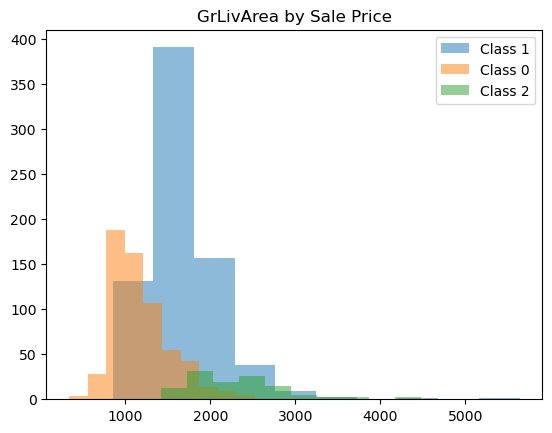

In [6]:
import matplotlib.pyplot as plt

for cls in df['SalePrice'].unique():
    subset = df[df['SalePrice'] == cls]
    plt.hist(subset['GrLivArea'], alpha=0.5, label=f'Class {cls}')

plt.legend()
plt.title("GrLivArea by Sale Price")
plt.show()

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

In [19]:
from sklearn.impute import SimpleImputer

X_original = df.drop(['SalePrice'], axis=1)

cat_cols = X_original.select_dtypes(include=['object']).columns
num_cols = X_original.select_dtypes(exclude=['object']).columns

num_imputer = SimpleImputer(strategy='median')
X_clean = X_original.copy()
X_clean[num_cols] = num_imputer.fit_transform(X_clean[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_clean[cat_cols] = cat_imputer.fit_transform(X_clean[cat_cols])

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = X_clean.copy()
X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])

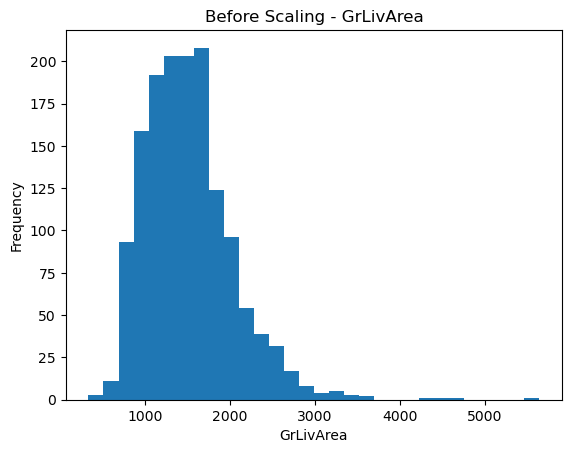

In [24]:
plt.hist(X_original['GrLivArea'], bins=30)
plt.title("Before Scaling - GrLivArea")
plt.xlabel("GrLivArea")
plt.ylabel("Frequency")
plt.show()

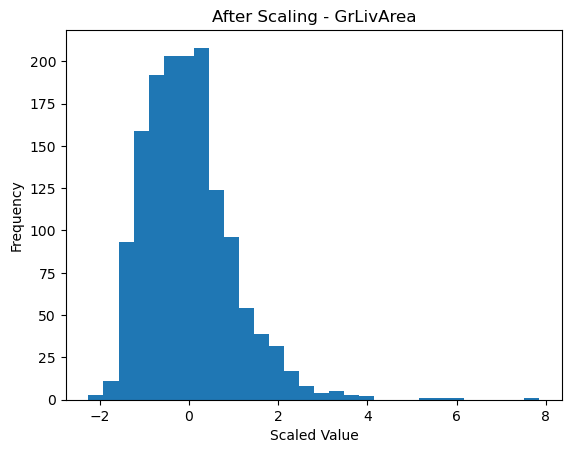

In [25]:
plt.hist(X_scaled['GrLivArea'], bins=30)
plt.title("After Scaling - GrLivArea")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.show()

In [26]:
X_encoded = pd.get_dummies(X_scaled, columns=cat_cols, drop_first=True)

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [28]:
y = df['SalePrice']
X = X_encoded.drop(['Id'], axis=1, errors='ignore')

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [31]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

val_preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
r2 = r2_score(y_val, val_preds)

print("Validation RMSE:", rmse)
print("Validation R^2:", r2)

Validation RMSE: 0.3043789995096011
Validation R^2: 0.7697231343283581


In [32]:
test = pd.read_csv("test.csv")

In [34]:
X_test_kaggle = test.copy()

X_test_kaggle[num_cols] = num_imputer.transform(X_test_kaggle[num_cols])
X_test_kaggle[cat_cols] = cat_imputer.transform(X_test_kaggle[cat_cols])

X_test_kaggle[num_cols] = scaler.transform(X_test_kaggle[num_cols])
X_test_kaggle = pd.get_dummies(X_test_kaggle, columns=cat_cols, drop_first=True)
X_test_kaggle = X_test_kaggle.reindex(columns=X.columns, fill_value=0)

In [35]:
predictions = model.predict(X_test_kaggle)

In [36]:
submission = pd.DataFrame({"Id": test["Id"],"SalePrice": predictions})
submission.to_csv("submission.csv", index=False)